### [Mastering Modern Portfolio Theory: Enhance Your Investments](https://wire.insiderfinance.io/mastering-modern-portfolio-theory-enhance-your-investments-0ef69a659e54)

> Learn portfolio risk calculations, optimization, the Efficient Frontier, and CAPM insights

#### **Mathematics of MPT**

---
1. **Portfolio Return**

The return is simply the weighted average of individual returns.

$$ E[R_p] = \sum w_i E[R_i] = w^T mu $$ where,

  $w$: Vector of weights (e.g., [0.5, 0.5]).
  
  $mu$: Vector of expected returns.

---

2. **Portfolio Variance**

Risk is not the weighted average of individual volatilities. It depends on how assets interact (Covariance).

$$ \sigma_p² = w^T \Sigma w $$ where,

  $sigma$: The Covariance Matrix (an $(N \times N)$ matrix).

  $w$: The Weights Vector ($(N \times 1)$).

---

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
from scipy import stats
import scipy.optimize as sco
import matplotlib.pyplot as plt

from IPython.display import display

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)

# Set style
plt.style.use('seaborn-v0_8-darkgrid')

In [2]:
# 1. Fetch Data
tickers = ['AAPL', 'MSFT', 'GOOG', 'AMZN']
data = yf.download(tickers, start='2020-01-01', end='2023-12-31', progress=False)['Close']
returns = data.pct_change().dropna()

# 2. Annualized Statistics
# Expected Return (Mean daily return * 252)
mean_returns = returns.mean() * 252

# Covariance Matrix (Daily Covariance * 252)
cov_matrix = returns.cov() * 252

print("--- Covariance Matrix (Annualized) ---")
display(cov_matrix)

--- Covariance Matrix (Annualized) ---


Ticker,AAPL,AMZN,GOOG,MSFT
Ticker,,,,
AAPL,0.1127,0.0790,0.0774,0.0851
AMZN,0.0790,0.1420,0.0844,0.0835
GOOG,0.0774,0.0844,0.1120,0.0839
MSFT,0.0851,0.0835,0.0839,0.1064


##### **The Simulation Loop**

In [3]:
num_portfolios = 5000
results = np.zeros((3, num_portfolios)) # Rows: [Return, Volatility, Sharpe]

np.random.seed(42)

for i in range(num_portfolios):
    # 1. Generate Random Weights
    weights = np.random.random(4)
    weights /= np.sum(weights) # Normalize to sum to 1

    # 2. Calculate Portfolio Return
    p_return = np.sum(mean_returns * weights)

    # 3. Calculate Portfolio Volatility (Std Dev)
    # Formula: sqrt(w.T * Cov * w)
    p_std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

    # 4. Store Results
    results[0,i] = p_return
    results[1,i] = p_std
    # Sharpe Ratio (assuming Rf=0 for simplicity)
    results[2,i] = results[0,i] / results[1,i]

# Convert to DataFrame for easier plotting
results_df = pd.DataFrame(results.T, columns=['Return', 'Volatility', 'Sharpe'])
display(results_df.head())

,Return,Volatility,Sharpe
0,0.2374,0.3071,0.7731
1,0.2660,0.3103,0.8572
2,0.2548,0.3077,0.8280
3,0.2715,0.3073,0.8835
4,0.2403,0.3056,0.7864


##### **Visualizing the Frontier**

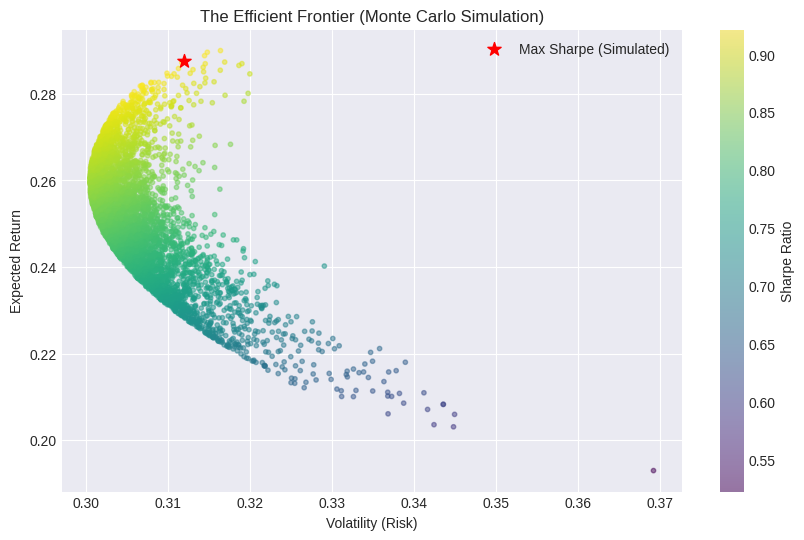

In [4]:
plt.figure(figsize=(10, 6))

# Scatter plot colored by Sharpe Ratio
plt.scatter(results_df['Volatility'], results_df['Return'],
            c=results_df['Sharpe'], cmap='viridis', marker='o', s=10, alpha=0.5)

plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Volatility (Risk)')
plt.ylabel('Expected Return')
plt.title('The Efficient Frontier (Monte Carlo Simulation)')

# Mark the Best Portfolio found in simulation
max_sharpe_idx = results_df['Sharpe'].idxmax()
max_sharpe_port = results_df.iloc[max_sharpe_idx]

plt.scatter(max_sharpe_port['Volatility'], max_sharpe_port['Return'],
            c='red', s=100, marker='*', label='Max Sharpe (Simulated)')

plt.legend()
plt.show()

##### **Portfolio Optimization**

In [5]:
def get_portfolio_stats(weights, mean_returns, cov_matrix, rf_rate=0):
    """
    Returns [Portfolio Return, Portfolio Volatility, Sharpe Ratio]
    """
    weights = np.array(weights)
    port_return = np.sum(mean_returns * weights)
    port_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

    # Sharpe Ratio (Return - Rf) / Volatility
    sharpe = (port_return - rf_rate) / port_volatility

    return [port_return, port_volatility, sharpe]

# Objective Function 1: Negative Sharpe (for Maximization)
def neg_sharpe(weights, mean_returns, cov_matrix, rf_rate=0):
    # We return the negative because scipy minimizes
    return -get_portfolio_stats(weights, mean_returns, cov_matrix, rf_rate)[2]

# Objective Function 2: Volatility (for Minimization)
def minimize_volatility(weights, mean_returns, cov_matrix):
    return get_portfolio_stats(weights, mean_returns, cov_matrix)[1]

##### **Constraints and Bounds**

**_Constraints_**: The weights must sum to 1 (100% invested).

- type: eq means “Equality Constraint”.
- fun: lambda x: np.sum(x) — 1 means the result must be 0.

**_Bounds_**: No short selling (Weights between 0 and 1).

If we wanted short selling, we would set bounds to (-1, 1).

In [6]:
# Number of assets
num_assets = len(tickers)

# 1. Constraints: Sum of weights = 1
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})

# 2. Bounds: Each weight between 0 and 1
bounds = tuple((0, 1) for _ in range(num_assets))

# 3. Initial Guess: Equal weights (Start the search here)
init_guess = num_assets * [1. / num_assets,]

##### **Running the Optimization**

##### **_Finding the Maximum Sharpe Portfolio_**

In [7]:
# Minimize the Negative Sharpe
opt_sharpe = sco.minimize(neg_sharpe,
                          init_guess,
                          args=(mean_returns, cov_matrix),
                          method='SLSQP',
                          bounds=bounds,
                          constraints=constraints)

# Extract Results
max_sharpe_weights = opt_sharpe.x
max_sharpe_stats = get_portfolio_stats(max_sharpe_weights, mean_returns, cov_matrix)

print("--- Maximum Sharpe Portfolio ---")
print(f"Return:     {max_sharpe_stats[0]*100:.2f}%")
print(f"Volatility: {max_sharpe_stats[1]*100:.2f}%")
print(f"Sharpe:     {max_sharpe_stats[2]:.2f}")
print("\nOptimal Weights:")
for ticker, weight in zip(tickers, max_sharpe_weights):
    print(f"{ticker}: {weight*100:.2f}%")

--- Maximum Sharpe Portfolio ---
Return:     28.91%
Volatility: 31.30%
Sharpe:     0.92

Optimal Weights:
AAPL: 59.24%
MSFT: 0.00%
GOOG: 1.29%
AMZN: 39.47%


**_Finding the Minimum Volatility Portfolio_**

In [8]:
# Minimize Volatility
opt_vol = sco.minimize(minimize_volatility,
                       init_guess,
                       args=(mean_returns, cov_matrix),
                       method='SLSQP',
                       bounds=bounds,
                       constraints=constraints)

min_vol_weights = opt_vol.x
min_vol_stats = get_portfolio_stats(min_vol_weights, mean_returns, cov_matrix)

print("\n--- Minimum Volatility Portfolio ---")
print(f"Return:     {min_vol_stats[0]*100:.2f}%")
print(f"Volatility: {min_vol_stats[1]*100:.2f}%")
print(f"Sharpe:     {min_vol_stats[2]:.2f}")


--- Minimum Volatility Portfolio ---
Return:     26.01%
Volatility: 30.05%
Sharpe:     0.87


#### **Visualizing the Optimal Portfolios**

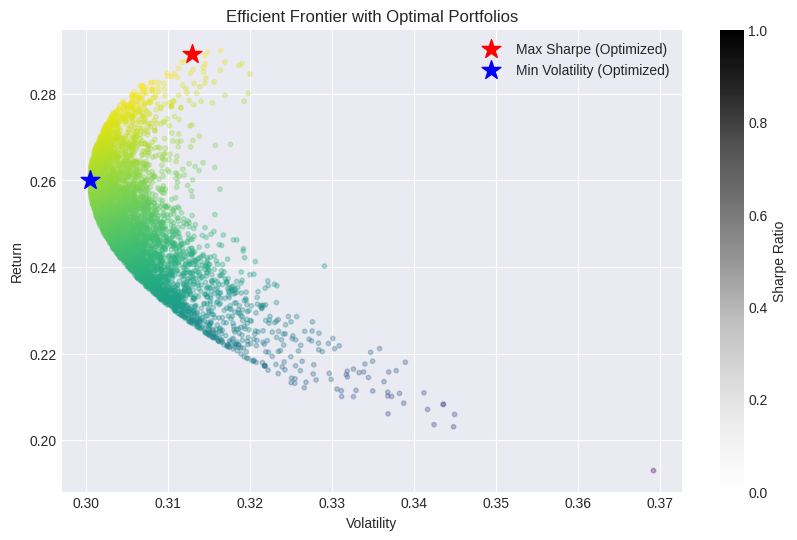

In [9]:
plt.figure(figsize=(10, 6))

# 1. Plot the Monte Carlo Cloud (from Part 1)
plt.scatter(results_df['Volatility'], results_df['Return'],
            c=results_df['Sharpe'], cmap='viridis', marker='o', s=10, alpha=0.3)

# 2. Plot Max Sharpe (Red Star)
plt.scatter(max_sharpe_stats[1], max_sharpe_stats[0],
            marker='*', color='red', s=200, label='Max Sharpe (Optimized)')

# 3. Plot Min Volatility (Blue Star)
plt.scatter(min_vol_stats[1], min_vol_stats[0],
            marker='*', color='blue', s=200, label='Min Volatility (Optimized)')

plt.title("Efficient Frontier with Optimal Portfolios")
plt.xlabel("Volatility")
plt.ylabel("Return")
plt.colorbar(label='Sharpe Ratio')
plt.legend()
plt.show()

#### **The Capital Asset Pricing Model (CAPM)**

The CAPM Formula:

  $$E[R_i] = R_f + beta_i (E[R_m] — R_f)$$, where

$E[R_i]$: Expected Return of the asset.

$R_f$: Risk-Free Rate.

$beta_i$: Beta (Sensitivity to the market).

$(E[R_m] — R_f)$: Market Risk Premium.

Beta measures how much an asset moves when the market moves.

$beta = 1$: Moves exactly with the market (e.g., an Index Fund).

$beta > 1$: Amplified volatility (e.g., Tech stocks, Crypto). If Market +1%, Asset +1.5%.

$beta < 1$: Defensive (e.g., Utilities, Gold). If Market -1%, Asset -0.5%.

$beta = 0$: Uncorrelated (e.g., Cash).

##### **Calculating Beta and Alpha**

Beta is the Slope and Alpha is the Intercept of a linear regression between the Stock’s return ($Y$) and the Market’s return ($X$).

$$R_{stock} = alpha + beta times R_{market} + epsilon$$


  Beta ($beta$): The systemic risk exposure.

  Alpha ($alpha$): The “Excess Return” not explained by the market movements. This is the Quant’s Holy Grail. A positive alpha implies the manager has skill (or luck).

In [10]:
# 1. Fetch Data (Stock vs. Benchmark)
tickers = ['NVDA', 'SPY']
data = yf.download(tickers, start='2020-01-01', end='2023-12-31', progress=False)['Close']
returns = data.pct_change().dropna()

# 2. Prepare Regression Arrays
# X = Market Returns (Independent Variable)
X = returns['SPY'].values

# Y = Stock Returns (Dependent Variable)
Y = returns['NVDA'].values

# 3. Perform Linear Regression
slope, intercept, r_value, p_value, std_err = stats.linregress(X, Y)

beta = slope
alpha = intercept
r_squared = r_value ** 2

print(f"--- CAPM Regression Results (NVDA vs SPY) ---")
print(f"Beta (Systematic Risk): {beta:.4f}")
print(f"Alpha (Daily Excess):   {alpha:.5f}")
print(f"R-Squared (Fit):        {r_squared:.4f}")

--- CAPM Regression Results (NVDA vs SPY) ---
Beta (Systematic Risk): 1.7181
Alpha (Daily Excess):   0.00175
R-Squared (Fit):        0.5140


##### **Visualizing the Regression Line**

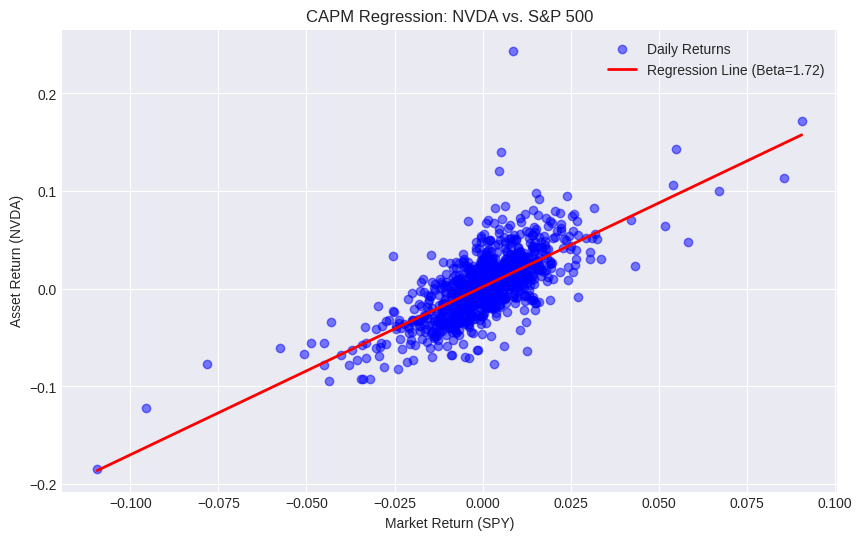

In [11]:
plt.figure(figsize=(10, 6))

# 1. Scatter Plot of Daily Returns
plt.scatter(X, Y, alpha=0.5, color='blue', label='Daily Returns')

# 2. Regression Line (y = mx + b)
# We generate points for the line using the min/max of X
x_line = np.linspace(X.min(), X.max(), 100)
y_line = (beta * x_line) + alpha

plt.plot(x_line, y_line, color='red', linewidth=2, label=f'Regression Line (Beta={beta:.2f})')

plt.title("CAPM Regression: NVDA vs. S&P 500")
plt.xlabel("Market Return (SPY)")
plt.ylabel("Asset Return (NVDA)")
plt.legend()
plt.grid(True)
plt.show()

##### **The Rolling Beta**

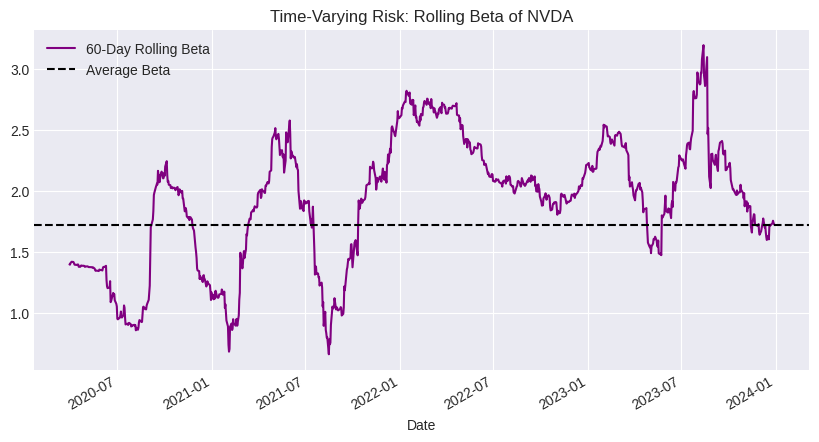

In [12]:
# Calculate Rolling 60-Day Beta
# Covariance / Variance
rolling_cov = returns['NVDA'].rolling(window=60).cov(returns['SPY'])
rolling_var = returns['SPY'].rolling(window=60).var()

rolling_beta = rolling_cov / rolling_var

plt.figure(figsize=(10, 5))
rolling_beta.plot(color='purple', label='60-Day Rolling Beta')
plt.axhline(beta, color='black', linestyle='--', label='Average Beta')
plt.title("Time-Varying Risk: Rolling Beta of NVDA")
plt.legend()
plt.show()

#### **Commodity Prices**

In [13]:
# 1. Fetch Data
tickers = ['SPY', 'TLT', 'GLD']
data = yf.download(tickers, start='2020-01-01', end='2023-12-31', progress=False)['Close']
returns = data.pct_change().dropna()

# 2. Statistics (Annualized)
mean_returns = returns.mean() * 252
cov_matrix = returns.cov() * 252

print("--- Annualized Expected Returns ---")
display(mean_returns)

--- Annualized Expected Returns ---


,0
Ticker,
GLD,0.0834
SPY,0.1369
TLT,-0.0422


In [14]:
def get_port_stats(weights):
    weights = np.array(weights)
    ret = np.sum(mean_returns * weights)
    vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return ret, vol

def robo_advisor(target_volatility):
    num_assets = len(tickers)

    # Objective: Minimize Negative Return (aka Maximize Return)
    def neg_return(weights):
        return -get_port_stats(weights)[0]

    # Constraints
    constraints = (
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},              # Sum weights = 1
        {'type': 'eq', 'fun': lambda x: get_port_stats(x)[1] - target_volatility} # Vol = Target
    )

    # Bounds (0% to 100% allocation, no shorting)
    bounds = tuple((0, 1) for _ in range(num_assets))

    # Initial Guess
    init_guess = num_assets * [1. / num_assets,]

    # Run Optimization
    result = sco.minimize(neg_return, init_guess, method='SLSQP',
                          bounds=bounds, constraints=constraints)

    return result.x

In [15]:
# Define Risk Profiles (Target Volatility)
profiles = {
    "Conservative (Vol=5%)": 0.05,
    "Balanced (Vol=10%)": 0.10,
    "Aggressive (Vol=15%)": 0.15
}

allocations = {}

print("--- Robo-Advisor Recommendations ---")
for profile, target_vol in profiles.items():
    try:
        weights = robo_advisor(target_vol)
        allocations[profile] = weights

        # Print Result
        ret, vol = get_port_stats(weights)
        print(f"\n{profile}:")
        print(f"  Exp Return: {ret*100:.2f}%")
        print(f"  Allocation: SPY {weights[1]*100:.0f}% | TLT {weights[2]*100:.0f}% | GLD {weights[0]*100:.0f}%")

    except Exception as e:
        print(f"Could not solve for {profile}. Target might be infeasible.")

--- Robo-Advisor Recommendations ---

Conservative (Vol=5%):
  Exp Return: 5.40%
  Allocation: SPY 28% | TLT 35% | GLD 37%

Balanced (Vol=10%):
  Exp Return: 5.40%
  Allocation: SPY 28% | TLT 35% | GLD 37%

Aggressive (Vol=15%):
  Exp Return: 11.20%
  Allocation: SPY 53% | TLT 0% | GLD 47%


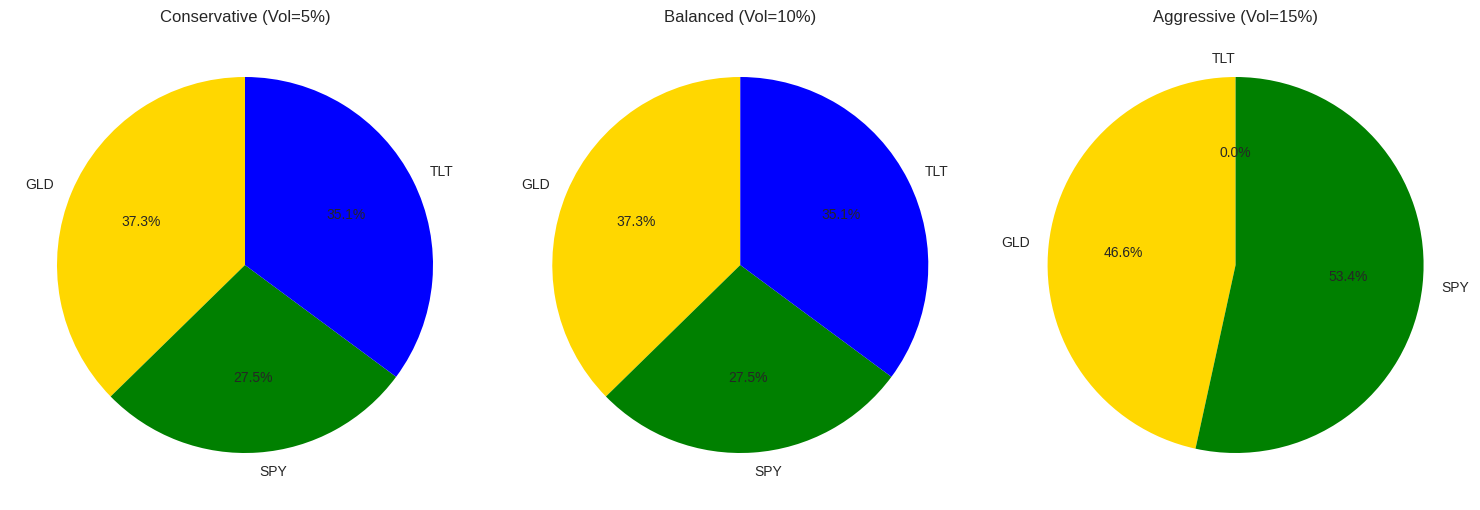

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (profile, weights) in enumerate(allocations.items()):
    # We use tickers order from yfinance download (alphabetical: GLD, SPY, TLT)
    # Check your specific download order! yfinance sorts columns alphabetically.
    # In this run: GLD (0), SPY (1), TLT (2)
    labels = ['GLD', 'SPY', 'TLT']

    axes[i].pie(weights, labels=labels, autopct='%1.1f%%', startangle=90, colors=['gold', 'green', 'blue'])
    axes[i].set_title(profile)

plt.tight_layout()
plt.show()